In [28]:
import numpy as np
from skimage.io import imread
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [2]:
image = imread("screen_from_vid.jpg")[...,0].astype(np.uint8) / 255

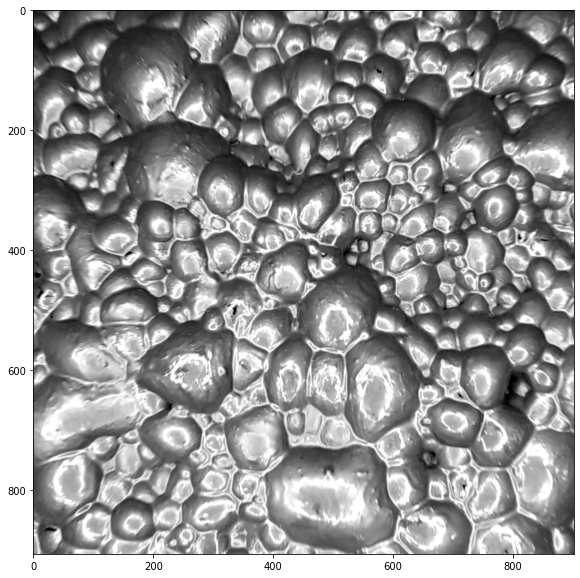

In [3]:
plt.figure(figsize=(10, 10))
plt.imshow(image, cmap='gray')
plt.show()

In [4]:
def create_high_pass(circle_size, image_shape):
    x, y = image_shape[0], image_shape[1]
    e_x,e_y = circle_size, circle_size
    bbox=((x/2)-(e_x/2),(y/2)-(e_y/2),(x/2)+(e_x/2),(y/2)+(e_y/2))
    high_pass=Image.new("L",(image_shape[1], image_shape[0]), color=1)
    draw1=ImageDraw.Draw(high_pass)
    draw1.ellipse(bbox, fill=0)
    high_pass = np.array(high_pass)
    return high_pass

In [29]:
def edges_with_fft(image, high_pass_size):
    res_fft = np.fft.fft2(image)
    res_fft_shift = np.fft.fftshift(res_fft)
    high_pass = create_high_pass(high_pass_size, image.shape)
    fft_img_shift_mod = np.empty(image.shape, dtype=complex)
    fft_img_shift_mod.real = res_fft_shift.real * high_pass
    fft_img_shift_mod.imag = res_fft_shift.imag * high_pass
    fft_img_mod = np.fft.ifftshift(fft_img_shift_mod)
    img_mod = np.fft.ifft2(fft_img_mod)
    img_mod = np.abs(img_mod)
    return img_mod

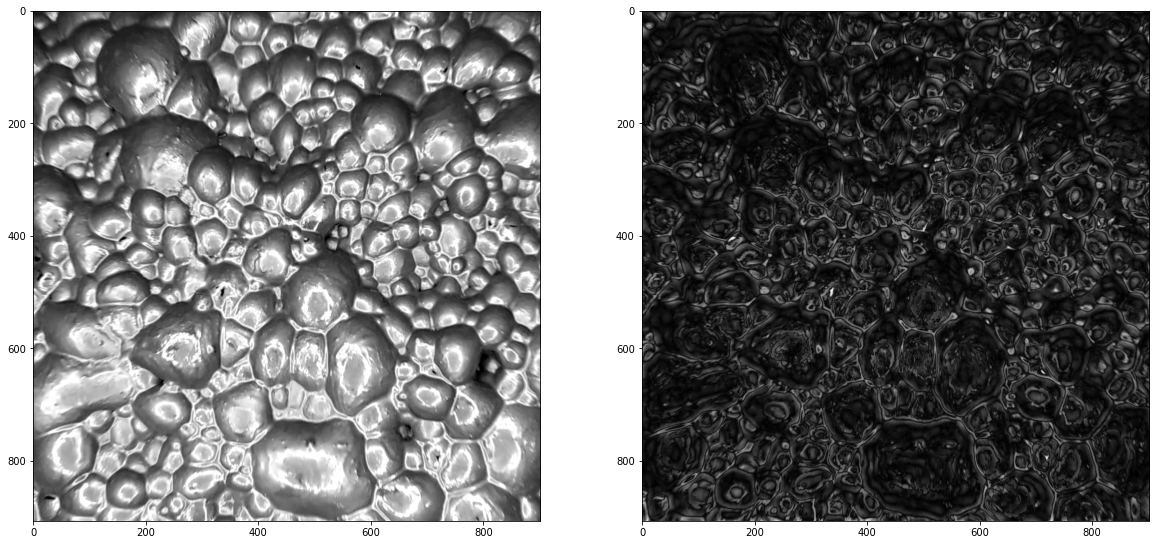

In [143]:
image_edges = edges_with_fft(image, high_pass_size=50)
plt.figure(figsize=(20, 20))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.subplot(122)
plt.imshow(image_edges, cmap='gray')
plt.show()

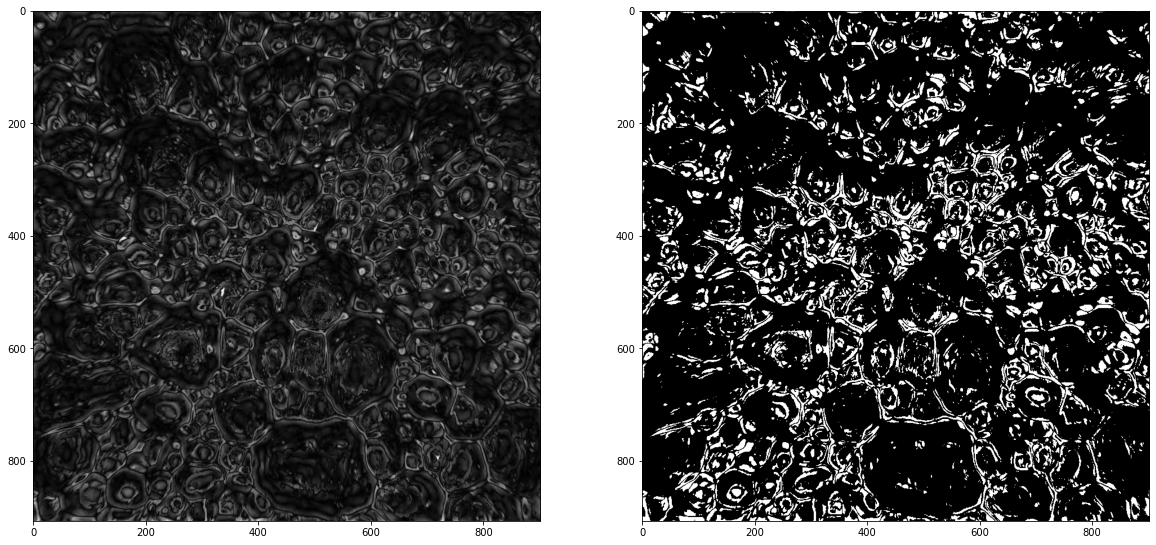

In [144]:
thresh = 0.18
image_edges_thresh = image_edges > thresh

plt.figure(figsize=(20, 20))
plt.subplot(121)
plt.imshow(image_edges, cmap='gray')
plt.subplot(122)
plt.imshow(image_edges_thresh, cmap='gray')
plt.show()